# PROJETO

Tratamento e análise de dados com Pandas

1. Procurar um dataset (Conjunto de dados) interessante;
    - Kaggle;
    - UCI Datasets; 
    - IBGE;
    - Outras fontes de interesse. 
2. Descrever os dados (nulos, valores distintos, tipos de variáveis...);
3. Fazer o tratamento de qualidade dos dados (Remover nulos, remover valores constantes, ...)
4. Levantar 10 perguntas sobre o dataset e responder utilizado filtragens, agrupamentos e transformações no Pandas.

Entrega: 

- Repositório do github (Envie o link do repositório);
- Pelo menos 3 commits no github ;
- No repositório deve conter o dataset e o arquivo .ipynb;
- Entrega até o dia 03/10 no LMS;

In [1]:
import pandas as pd

bank = pd.read_csv("bank.csv", sep = ";")

bank.shape

(4521, 17)

In [2]:
# Quero ver as 5 primeiras linhas
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [3]:
# quero ver a 10 ultimas linhas 
bank.tail(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4511,46,blue-collar,married,secondary,no,668,yes,no,unknown,15,may,1263,2,-1,0,unknown,yes
4512,40,blue-collar,married,secondary,no,1100,yes,no,unknown,29,may,660,2,-1,0,unknown,no
4513,49,blue-collar,married,secondary,no,322,no,no,cellular,14,aug,356,2,-1,0,unknown,no
4514,38,blue-collar,married,secondary,no,1205,yes,no,cellular,20,apr,45,4,153,1,failure,no
4515,32,services,single,secondary,no,473,yes,no,cellular,7,jul,624,5,-1,0,unknown,no
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no
4520,44,entrepreneur,single,tertiary,no,1136,yes,yes,cellular,3,apr,345,2,249,7,other,no


In [4]:
#Quantos dados são nulos

bank.isnull().sum()
# praticamente não tem dados nulos

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [5]:
# Quantos valores desconhecidos em cada campo
(bank == "unknown").sum()

age             0
job            38
marital         0
education     187
default         0
balance         0
housing         0
loan            0
contact      1324
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     3705
y               0
dtype: int64

In [6]:
#Tratamento de dados
bank["education"] = bank["education"].replace("unknown", "Não informado")
bank[bank["education"] == "Não informado"].head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
20,38,management,divorced,Não informado,no,0,yes,no,cellular,18,nov,96,2,-1,0,unknown,no
27,67,retired,married,Não informado,no,696,no,no,telephone,17,aug,119,1,105,2,failure,no
49,61,admin.,married,Não informado,no,4629,yes,no,cellular,27,jan,181,1,92,1,success,yes
132,43,blue-collar,married,Não informado,yes,-715,yes,no,unknown,30,may,67,3,-1,0,unknown,no
133,48,admin.,married,Não informado,no,0,yes,no,cellular,8,may,85,1,168,2,failure,no


In [7]:
#Informações gerais do dataset
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


In [8]:
# Descrição das idades (age)
bank["age"].describe()

count    4521.000000
mean       41.170095
std        10.576211
min        19.000000
25%        33.000000
50%        39.000000
75%        49.000000
max        87.000000
Name: age, dtype: float64

In [9]:
# Informações gerais do data set, com as informações de desvio padrão e quartis campo a campo
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [10]:
# Descrição dos trabalhos (job)
bank["job"].describe()

count           4521
unique            12
top       management
freq             969
Name: job, dtype: object

In [11]:
# Descrição do estado civil (marital)
bank["marital"].describe()

count        4521
unique          3
top       married
freq         2797
Name: marital, dtype: object

In [12]:
# Descrição do nível escolar (education)
bank["education"].describe()

count          4521
unique            4
top       secondary
freq           2306
Name: education, dtype: object

In [13]:
# Descrição se possui operação de crédito (defaut)
bank["default"].describe()

count     4521
unique       2
top         no
freq      4445
Name: default, dtype: object

In [14]:
# Este é o campo do saldo financeiro (balance)
bank["balance"].describe()

count     4521.000000
mean      1422.657819
std       3009.638142
min      -3313.000000
25%         69.000000
50%        444.000000
75%       1480.000000
max      71188.000000
Name: balance, dtype: float64

In [15]:
#Percentual por estado civil
bank["marital"].value_counts(normalize= True).mul(100).round(2)

marital
married     61.87
single      26.45
divorced    11.68
Name: proportion, dtype: float64

In [16]:
#Percentual por escolaridade
bank["education"].value_counts(normalize= True).mul(100).round(2)

education
secondary        51.01
tertiary         29.86
primary          15.00
Não informado     4.14
Name: proportion, dtype: float64

Até aqui foi a exploração dos dados.
Não há dados nulos nessa base. Não identifiquei necessidade de excluir nenhum coluna da base de dados ou coluna com dados constantes. Para alguns campos há uma quantidade grande de informações como desconhecido, o que pode atrapalhar a análise.

Pergunta 1)
Determine o saldo médio por escolaridade.

In [17]:
bank.groupby('education')['balance'].mean().round(2)

education
Não informado    1701.25
primary          1411.54
secondary        1196.81
tertiary         1775.42
Name: balance, dtype: float64

Pergunta 2)
Qual é a média de saldo bancário para cada profissão? Em ordem decrescente.

In [18]:
bank.groupby('job')['balance'].mean().round(2).reset_index().sort_values(by='balance', ascending=False)

,job,balance
5,retired,2319.19
3,housemaid,2083.80
4,management,1766.93
2,entrepreneur,1645.12
8,student,1543.82
11,unknown,1501.71
6,self-employed,1392.41
9,technician,1331.00
0,admin.,1226.74
7,services,1103.96


Pergunta 3)
Qual o saldo total somado de todas as pessoas que estão inadimplentes comparado as que não estão inadimplentes. Informe também a quantidade de pessoas.

In [19]:
bank.groupby('default')['balance'].agg(quantidade='count',media='mean',saldo_total='sum')

,quantidade,media,saldo_total
default,,,
no,4445,1450.550956,6447699
yes,76,-208.723684,-15863


Pergunta 4) 
Quantos clientes com menos de 30 anos possuem empréstimo de habitação?

In [20]:
clientes_jovens_housing=bank[(bank['age'] < 30) & (bank['housing'] == 'yes')]
quantidade = clientes_jovens_housing.shape[0]
print(f"Quantidade de clientes: {quantidade}")

Quantidade de clientes: 282


Pergunta 5)
Quais são os 5 clientes com maior duração de chamada (duration) na campanha atual, mostrando apenas a idade, profissão e a duração?

In [21]:
bank.sort_values(by='duration', ascending=False)[['age', 'job', 'duration']].head(5)


,age,job,duration
568,59,unemployed,3025
3673,36,entrepreneur,2769
4123,47,blue-collar,2456
980,43,management,2087
3853,54,technician,2029


Pergunta 6:
Qual o nível escolar predominante entre os clientes que aceitaram a oferta na campanha?

In [22]:
(bank[bank['y'] == 'yes']['education'].value_counts(normalize=True) * 100).round(2)

education
secondary        47.02
tertiary         37.04
primary          12.28
Não informado     3.65
Name: proportion, dtype: float64

Pergunta 7:
Quais as 5 profissões mais frequêntes para os clientes com saldo negativo?

In [23]:
bank[bank['balance'] < 0]['job'].value_counts().head(5)

job
blue-collar    106
management      66
technician      60
services        47
admin.          37
Name: count, dtype: int64

Pergunta 8:
Qual mês teve mais contatos realizados pelo banco? Faça um gráfico de barras.

In [24]:
bank["month"].value_counts()

month
may    1398
jul     706
aug     633
jun     531
nov     389
apr     293
feb     222
jan     148
oct      80
sep      52
mar      49
dec      20
Name: count, dtype: int64

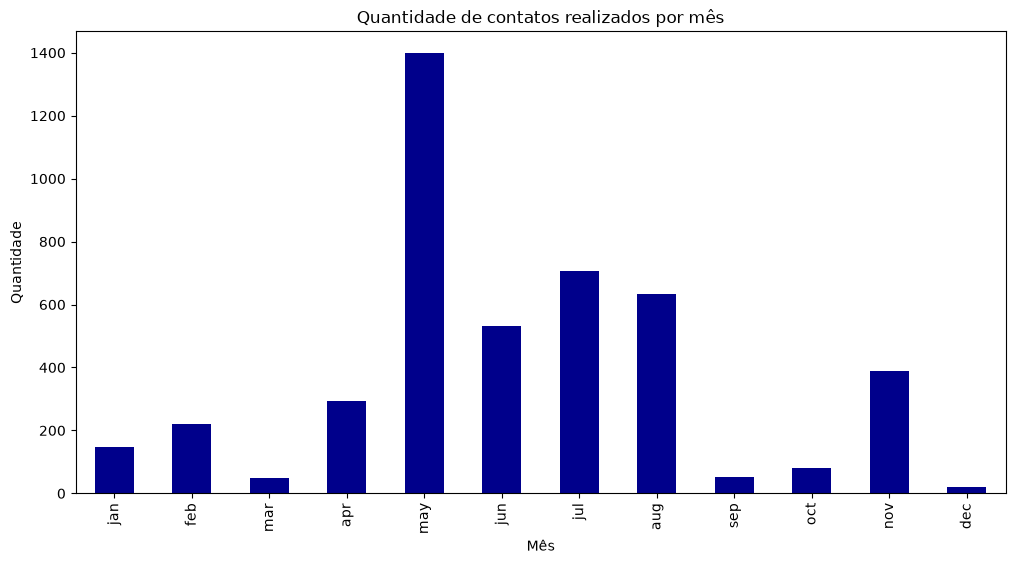

In [26]:
import matplotlib.pyplot as plt
ordem_meses = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
contatos_mes = (bank["month"].value_counts().reindex(ordem_meses))
plt.figure(figsize=(12,6))
contatos_mes.plot(kind="bar", color="darkblue")
plt.title("Quantidade de contatos realizados por mês")
plt.xlabel("Mês")
plt.ylabel("Quantidade")
plt.show()

Pergunta 9:
Faça um top 10 das profissões com mais aceites das campanhas do banco? Utilize um gráfico para demonstrar.

In [27]:
bank[bank["y"] == "yes"]["job"].value_counts()

job
management       131
technician        83
blue-collar       69
admin.            58
retired           54
services          38
self-employed     20
student           19
entrepreneur      15
housemaid         14
unemployed        13
unknown            7
Name: count, dtype: int64

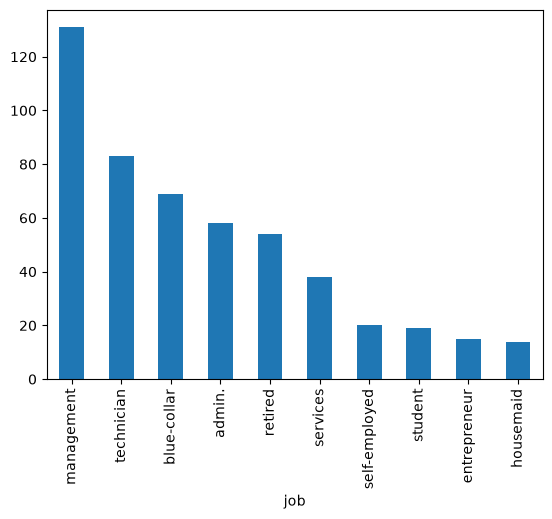

In [29]:
bank[bank["y"]=="yes"]["job"].value_counts().head(10).plot(kind="bar")
plt.show()

Pergunta 10)
Qual é o tempo de duração (duration) médio das chamadas para as pessoas que aceitaram (y='yes') verso as que rejeitaram?

In [30]:
bank.groupby('y')['duration'].mean().round(2)

y
no     226.35
yes    552.74
Name: duration, dtype: float64

Conclusões Finais:

Clientes com ensino superior possuem maior saldo médio.
O mês de maio concentrou a maior quantidade de contatos e muito acima dos demais.
Determinadas profissões apresentam maior taxa de aceitação.
Chamadas mais longas tendem a estar associadas a clientes que aceitaram a oferta.